# Student Dropout Prediction — Exploratory Data Analysis

**Goal:** Understand the UCI "Predict Students' Dropout and Academic Success" dataset before building any models.

We want to answer:
- What does the target variable look like? (class balance)
- Which features seem most related to dropout?
- Are there patterns in academic performance that flag at-risk students early?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 6)

df = pd.read_csv("../data/data.csv", sep=";")
print(f"Dataset shape: {df.shape[0]} students × {df.shape[1]} features")
df.head()

Dataset shape: 4424 students × 37 features


,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


## 1. Target Variable Distribution

The target has three classes: **Dropout**, **Graduate**, and **Enrolled** (still in school). Let's see how balanced they are.

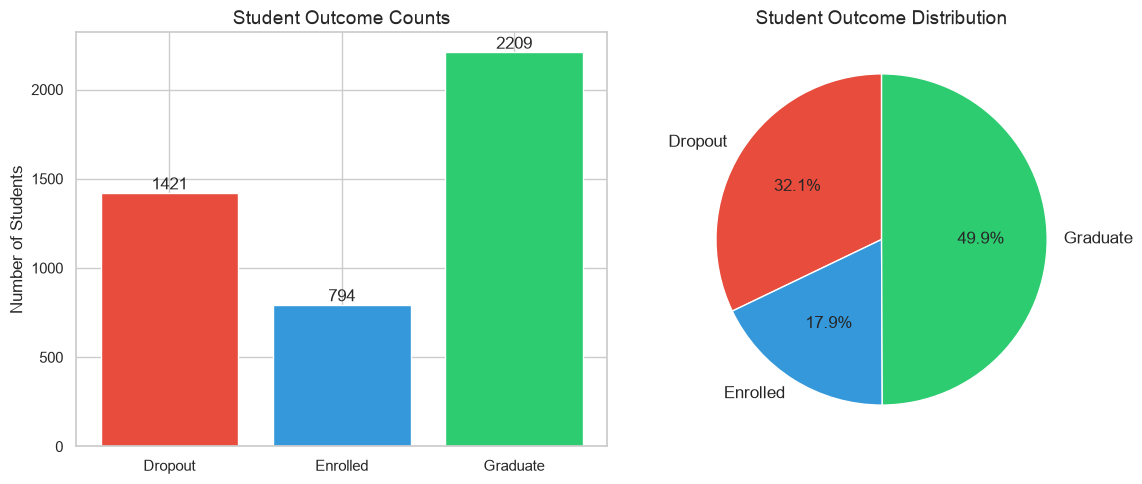


Dropout rate: 32.1%
Graduate rate: 49.9%
Still enrolled: 17.9%


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

colors = {"Dropout": "#e74c3c", "Graduate": "#2ecc71", "Enrolled": "#3498db"}
order = ["Dropout", "Enrolled", "Graduate"]

counts = df["Target"].value_counts()
ax = axes[0]
bars = ax.bar(order, [counts[t] for t in order], color=[colors[t] for t in order])
ax.bar_label(bars, fmt="%d", fontsize=12)
ax.set_title("Student Outcome Counts", fontsize=14)
ax.set_ylabel("Number of Students")

pcts = df["Target"].value_counts(normalize=True) * 100
ax = axes[1]
ax.pie([pcts[t] for t in order], labels=order, autopct="%.1f%%",
       colors=[colors[t] for t in order], startangle=90, textprops={"fontsize": 12})
ax.set_title("Student Outcome Distribution", fontsize=14)

plt.tight_layout()
plt.savefig("../figures/01_target_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nDropout rate: {pcts['Dropout']:.1f}%")
print(f"Graduate rate: {pcts['Graduate']:.1f}%")
print(f"Still enrolled: {pcts['Enrolled']:.1f}%")

## 2. Data Overview

Let's check data types, missing values, and basic statistics.

In [3]:
print("Missing values per column:")
missing = df.isnull().sum()
print(f"  Total missing: {missing.sum()}\n")

print("Data types:")
print(df.dtypes.value_counts().to_string())
print(f"\nBasic statistics for numerical features:")
df.describe().round(2)

Missing values per column:
  Total missing: 0

Data types:
int64      29
float64     7
str         1

Basic statistics for numerical features:


,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
count,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,...,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00
mean,1.18,18.67,1.73,8856.64,0.89,4.58,132.61,1.87,19.56,22.28,...,0.14,0.54,6.23,8.06,4.44,10.23,0.15,11.57,1.23,0.00
std,0.61,17.48,1.31,2063.57,0.31,10.22,13.19,6.91,15.60,15.34,...,0.69,1.92,2.20,3.95,3.01,5.21,0.75,2.66,1.38,2.27
min,1.00,1.00,0.00,33.00,0.00,1.00,95.00,1.00,1.00,1.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,7.60,-0.80,-4.06
25%,1.00,1.00,1.00,9085.00,1.00,1.00,125.00,1.00,2.00,3.00,...,0.00,0.00,5.00,6.00,2.00,10.75,0.00,9.40,0.30,-1.70
50%,1.00,17.00,1.00,9238.00,1.00,1.00,133.10,1.00,19.00,19.00,...,0.00,0.00,6.00,8.00,5.00,12.20,0.00,11.10,1.40,0.32
75%,1.00,39.00,2.00,9556.00,1.00,1.00,140.00,1.00,37.00,37.00,...,0.00,0.00,7.00,10.00,6.00,13.33,0.00,13.90,2.60,1.79
max,6.00,57.00,9.00,9991.00,1.00,43.00,190.00,109.00,44.00,44.00,...,12.00,19.00,23.00,33.00,20.00,18.57,12.00,16.20,3.70,3.51


## 3. Academic Performance: Dropout vs. Graduate

The strongest signals for dropout are usually in **academic performance** — courses approved and grades in the first two semesters. Let's compare these between students who dropped out and those who graduated.

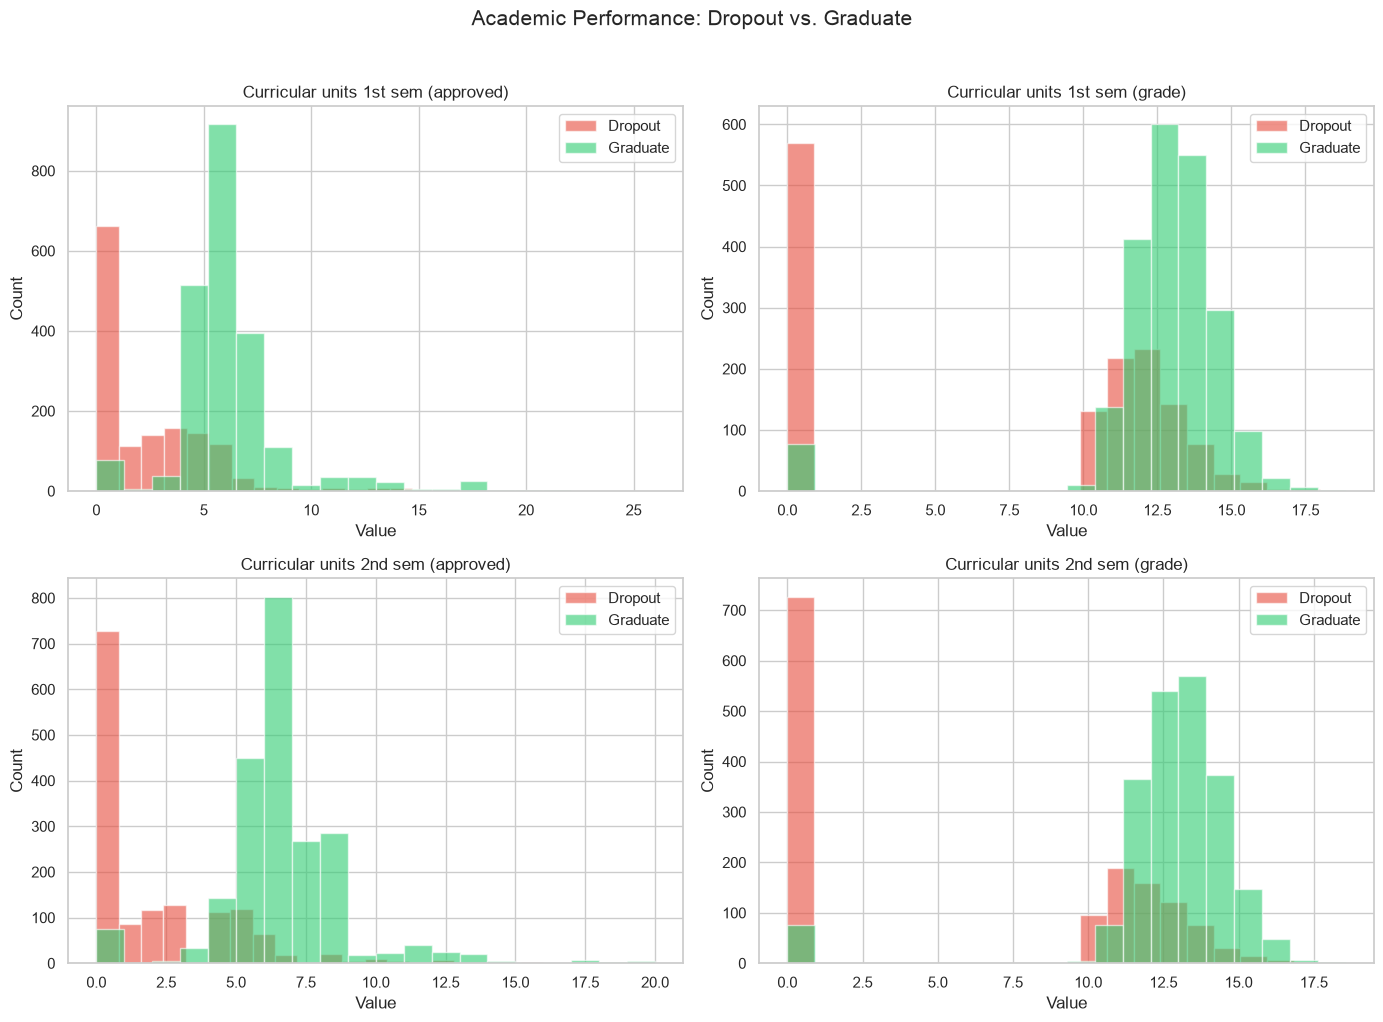

In [4]:
academic_cols = [
    "Curricular units 1st sem (approved)",
    "Curricular units 1st sem (grade)",
    "Curricular units 2nd sem (approved)",
    "Curricular units 2nd sem (grade)",
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
colors_list = ["#e74c3c", "#2ecc71"]

for ax, col in zip(axes.flat, academic_cols):
    for label, color in zip(["Dropout", "Graduate"], colors_list):
        subset = df[df["Target"] == label][col]
        ax.hist(subset, bins=20, alpha=0.6, label=label, color=color, edgecolor="white")
    ax.set_title(col, fontsize=12)
    ax.set_xlabel("Value")
    ax.set_ylabel("Count")
    ax.legend()

plt.suptitle("Academic Performance: Dropout vs. Graduate", fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig("../figures/02_academic_performance.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Demographic Factors

Let's look at how demographic features like **age**, **gender**, **scholarship status**, and **tuition payment** relate to dropout.

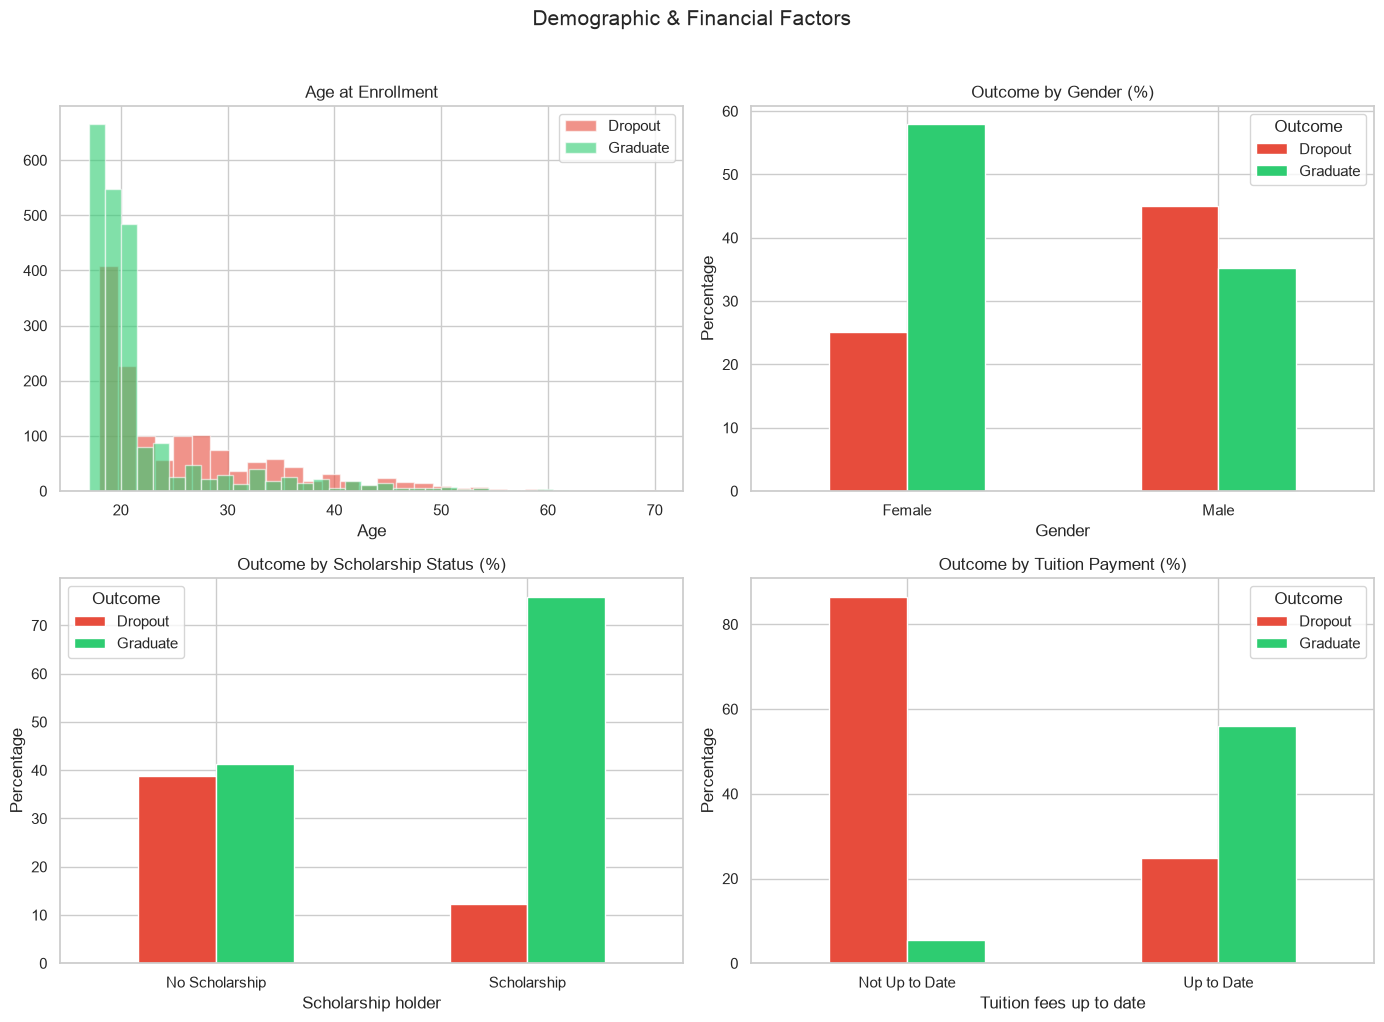

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Age distribution by outcome
ax = axes[0, 0]
for label, color in zip(["Dropout", "Graduate"], ["#e74c3c", "#2ecc71"]):
    subset = df[df["Target"] == label]["Age at enrollment"]
    ax.hist(subset, bins=30, alpha=0.6, label=label, color=color, edgecolor="white")
ax.set_title("Age at Enrollment", fontsize=12)
ax.set_xlabel("Age")
ax.legend()

# Gender vs outcome
ax = axes[0, 1]
gender_map = {0: "Female", 1: "Male"}
ct = pd.crosstab(df["Gender"].map(gender_map), df["Target"], normalize="index") * 100
ct[["Dropout", "Graduate"]].plot(kind="bar", ax=ax, color=["#e74c3c", "#2ecc71"], rot=0)
ax.set_title("Outcome by Gender (%)", fontsize=12)
ax.set_ylabel("Percentage")
ax.legend(title="Outcome")

# Scholarship holder vs outcome
ax = axes[1, 0]
sch_map = {0: "No Scholarship", 1: "Scholarship"}
ct2 = pd.crosstab(df["Scholarship holder"].map(sch_map), df["Target"], normalize="index") * 100
ct2[["Dropout", "Graduate"]].plot(kind="bar", ax=ax, color=["#e74c3c", "#2ecc71"], rot=0)
ax.set_title("Outcome by Scholarship Status (%)", fontsize=12)
ax.set_ylabel("Percentage")
ax.legend(title="Outcome")

# Tuition fees up to date vs outcome
ax = axes[1, 1]
tuit_map = {0: "Not Up to Date", 1: "Up to Date"}
ct3 = pd.crosstab(df["Tuition fees up to date"].map(tuit_map), df["Target"], normalize="index") * 100
ct3[["Dropout", "Graduate"]].plot(kind="bar", ax=ax, color=["#e74c3c", "#2ecc71"], rot=0)
ax.set_title("Outcome by Tuition Payment (%)", fontsize=12)
ax.set_ylabel("Percentage")
ax.legend(title="Outcome")

plt.suptitle("Demographic & Financial Factors", fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig("../figures/03_demographics.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Correlation Heatmap

Which features correlate most strongly with dropping out? We'll encode the target as binary (Dropout=1, Graduate=0) and look at correlations.

/var/folders/h4/ckq5mc9174lbp14hk6lsdh4m0000gn/T/ipykernel_25092/2790352353.py:11: UserWarning: Glyph 9 (	) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/h4/ckq5mc9174lbp14hk6lsdh4m0000gn/T/ipykernel_25092/2790352353.py:12: UserWarning: Glyph 9 (	) missing from font(s) Arial.
  plt.savefig("../figures/04_correlation_with_dropout.png", dpi=150, bbox_inches="tight")


/Users/mirlairias/student-dropout-prediction/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9 (	) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


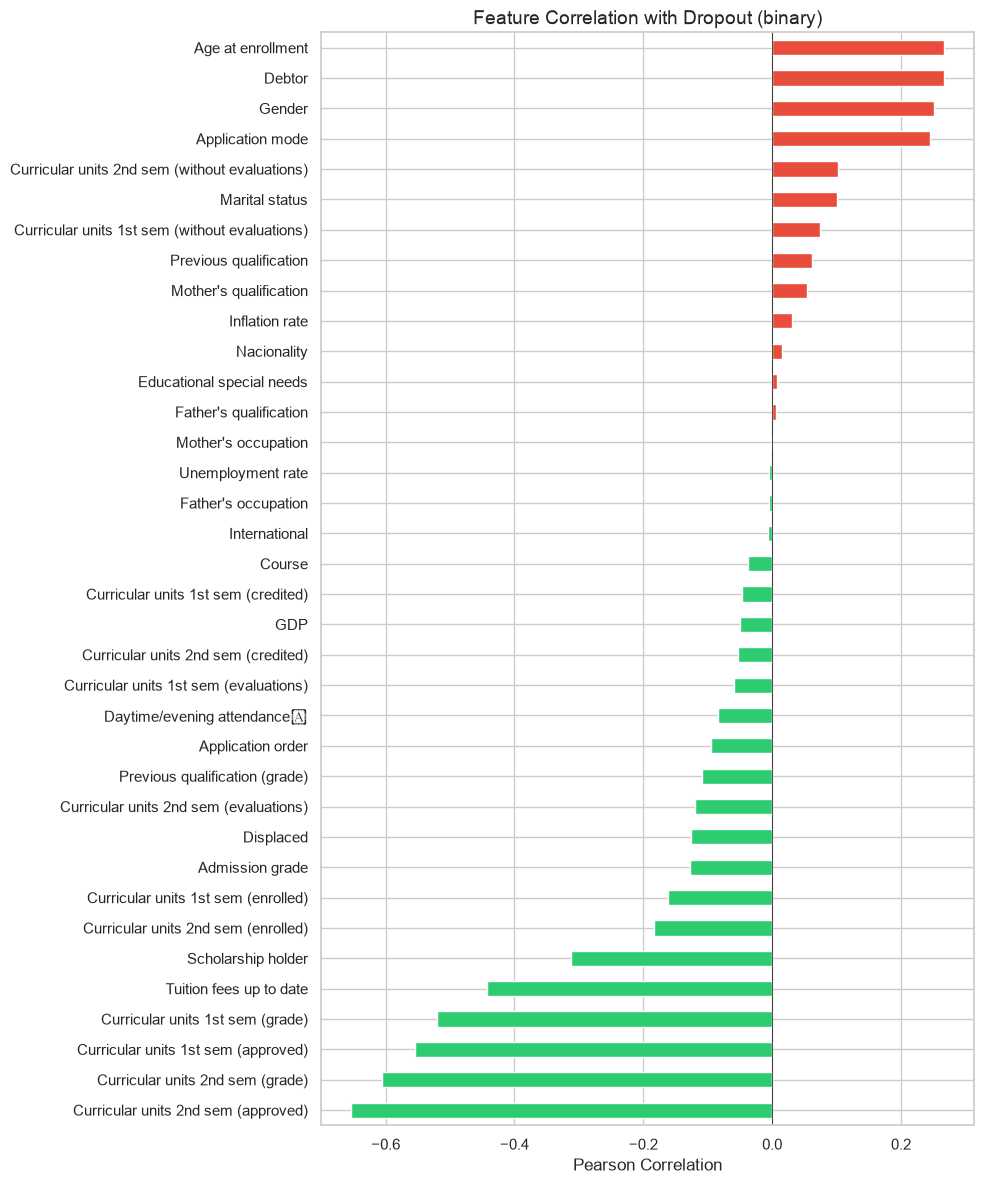


Top 10 features most correlated with DROPOUT (positive = higher → more dropout):
Inflation rate                                    0.030326
Mother's qualification                            0.053989
Previous qualification                            0.062323
Curricular units 1st sem (without evaluations)    0.074642
Marital status                                    0.100479
Curricular units 2nd sem (without evaluations)    0.102687
Application mode                                  0.244507
Gender                                            0.251955
Debtor                                            0.267207
Age at enrollment                                 0.267229

Top 10 features most correlated with GRADUATION (negative = higher → less dropout):
Curricular units 2nd sem (approved)   -0.653995
Curricular units 2nd sem (grade)      -0.605350
Curricular units 1st sem (approved)   -0.554881
Curricular units 1st sem (grade)      -0.519927
Tuition fees up to date               -0.442138
Sch

In [6]:
df_binary = df[df["Target"] != "Enrolled"].copy()
df_binary["Dropout"] = (df_binary["Target"] == "Dropout").astype(int)

correlations = df_binary.drop(columns=["Target"]).corr()["Dropout"].drop("Dropout").sort_values()

fig, ax = plt.subplots(figsize=(10, 12))
correlations.plot(kind="barh", ax=ax, color=correlations.apply(lambda x: "#e74c3c" if x > 0 else "#2ecc71"))
ax.set_title("Feature Correlation with Dropout (binary)", fontsize=14)
ax.set_xlabel("Pearson Correlation")
ax.axvline(x=0, color="black", linewidth=0.5)
plt.tight_layout()
plt.savefig("../figures/04_correlation_with_dropout.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nTop 10 features most correlated with DROPOUT (positive = higher → more dropout):")
print(correlations.tail(10).to_string())
print("\nTop 10 features most correlated with GRADUATION (negative = higher → less dropout):")
print(correlations.head(10).to_string())

## 6. Key Takeaways

Summary of findings from the exploration — these will guide our modeling decisions in the next notebook.

In [7]:
print("EDA Summary")
print("=" * 60)
print(f"Total students: {len(df)}")
print(f"Features: {df.shape[1] - 1}")
print(f"Missing values: {df.isnull().sum().sum()}")
print(f"\nTarget distribution:")
for t in ["Dropout", "Enrolled", "Graduate"]:
    n = (df["Target"] == t).sum()
    print(f"  {t}: {n} ({n/len(df)*100:.1f}%)")
print(f"\nFor binary modeling (Dropout vs Graduate):")
print(f"  Total: {len(df_binary)}")
print(f"  Dropout: {df_binary['Dropout'].sum()} ({df_binary['Dropout'].mean()*100:.1f}%)")
print(f"  Graduate: {(1-df_binary['Dropout']).sum().astype(int)} ({(1-df_binary['Dropout'].mean())*100:.1f}%)")
print(f"\nStrongest dropout predictors (by correlation):")
print(f"  Positive (↑ = more dropout): Tuition debt, age")
print(f"  Negative (↑ = less dropout): Semester grades, courses approved, tuition up to date")

EDA Summary
Total students: 4424
Features: 36
Missing values: 0

Target distribution:
  Dropout: 1421 (32.1%)
  Enrolled: 794 (17.9%)
  Graduate: 2209 (49.9%)

For binary modeling (Dropout vs Graduate):
  Total: 3630
  Dropout: 1421 (39.1%)
  Graduate: 2209 (60.9%)

Strongest dropout predictors (by correlation):
  Positive (↑ = more dropout): Tuition debt, age
  Negative (↑ = less dropout): Semester grades, courses approved, tuition up to date
